## Cataract CNN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [ ]:
import torch
from torch import nn
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import zipfile
import os

# Note: this notebook requires torch >= 1.10.0
torch.__version__

'2.5.1+cu121'

## Setting up the device

In [ ]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Extracting the Zip file

In [ ]:

def extract_zip(zip_path, extract_to='.'):
    """
    Extracts all files from a zip file to the specified directory.

    Parameters:
    - zip_path (str): The path to the zip file.
    - extract_to (str): The directory to extract the files to. Defaults to the current directory.
    """
    try:
        # Check if the zip file exists
        if not os.path.isfile(zip_path):
            print("The specified zip file does not exist.")
            return

        # Open the zip file
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Extract all files
            zip_ref.extractall(extract_to)
            print(f"All files have been extracted to '{extract_to}'")

    except zipfile.BadZipFile:
        print("The specified file is not a valid zip file.")

# Example usage
zip_file_path = '/content/drive/MyDrive/Dataset/Cataract/Eyes.zip'  # Replace with your zip file path
output_directory = '/content/drive/MyDrive/Dataset/Cataract'  # Replace with your desired extraction directory
extract_zip(zip_file_path, output_directory)

All files have been extracted to '/content/drive/MyDrive/Dataset/Cataract'


## Dataset

In [ ]:
dir_path = Path("/content/drive/MyDrive/Dataset/Cataract/Eyes")
train_dir = Path("/content/drive/MyDrive/Dataset/Cataract/Eyes/train/")
test_dir = Path("/content/drive/MyDrive/Dataset/Cataract/Eyes/test/")
val_dir = Path("/content/drive/MyDrive/Dataset/Cataract/Eyes/validation/")

### Inspecting the data

Random image path: /content/drive/MyDrive/Dataset/Cataract/Eyes/train/healthy/healthy-477.jpg
Image class: healthy
Image height: 62
Image width: 113


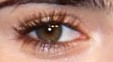

In [ ]:
import random
from PIL import Image
# Set seed
random.seed(42) # <- try changing this and see what happens

# 1. Get all image paths (* means "any combination")
image_path_list = list((dir_path).glob("*/*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

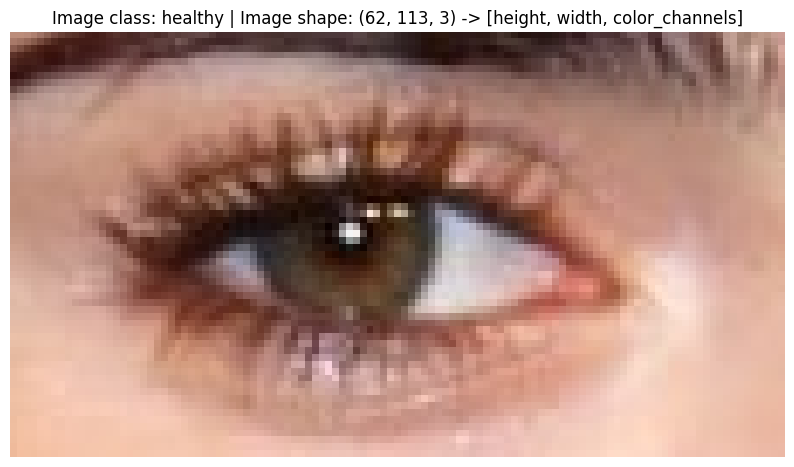

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

### Transforming the image into tensors

In [ ]:
# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 128, 128
    transforms.Resize(size=(128, 128)),
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

### Viewing the image after data transformation

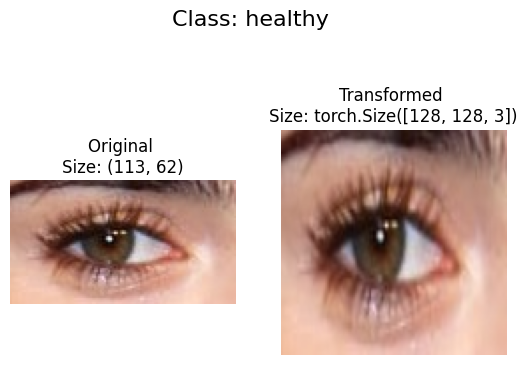

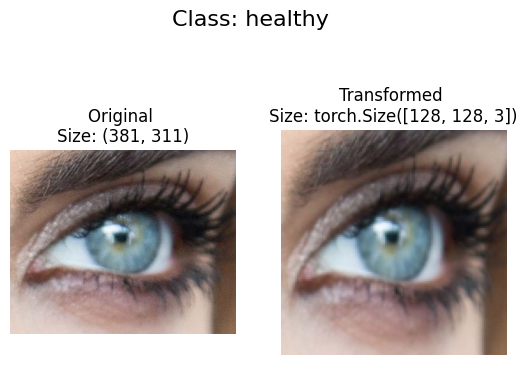

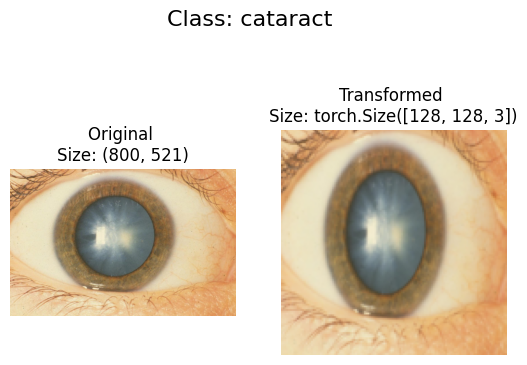

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

In [ ]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 565
    Root location: /content/drive/MyDrive/Dataset/Cataract/Eyes/train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 122
    Root location: /content/drive/MyDrive/Dataset/Cataract/Eyes/test
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [ ]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32, # how many samples per batch?
                              num_workers=1, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             num_workers=1,
                             shuffle=False) # don't usually need to shuffle testing data

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7beace29f010>,
 <torch.utils.data.dataloader.DataLoader at 0x7beacd64db10>)

In [ ]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Don't augment test data, only reshape
test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
class CataractCNN(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=0), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*29*29,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x)))

torch.manual_seed(42)
model_0 = CataractCNN(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units = 32,
                  output_shape=len(train_data.classes)).to(device)
model_0

CataractCNN(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=26912, out_features=2, bias=True)
  )
)

In [ ]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 128, 128])

Output logits:
tensor([[0.0139, 0.0054]])

Output prediction probabilities:
tensor([[0.5021, 0.4979]])

Output prediction label:
tensor([0])

Actual label:
0


In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          save_path: str = ""):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

     # Initialize variable to track the best test accuracy
    best_test_acc = 0.0

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), save_path)  # Save the model
            print(f"New best test accuracy: {test_acc:.4f}, model saved to {save_path}")

    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 10

# Recreate an instance of TinyVGG
model_0 = CataractCNN(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=32,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        save_path = "/content/drive/MyDrive/Models/cataract/CNN/cnn.pth")

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6623 | train_acc: 0.5866 | test_loss: 0.5797 | test_acc: 0.6761
New best test accuracy: 0.6761, model saved to /content/drive/MyDrive/Models/cataract/CNN/cnn.pth
Epoch: 2 | train_loss: 0.4750 | train_acc: 0.7767 | test_loss: 0.3682 | test_acc: 0.8678
New best test accuracy: 0.8678, model saved to /content/drive/MyDrive/Models/cataract/CNN/cnn.pth
Epoch: 3 | train_loss: 0.3798 | train_acc: 0.8462 | test_loss: 0.3582 | test_acc: 0.8816
New best test accuracy: 0.8816, model saved to /content/drive/MyDrive/Models/cataract/CNN/cnn.pth
Epoch: 4 | train_loss: 0.3488 | train_acc: 0.8523 | test_loss: 0.3453 | test_acc: 0.8912
New best test accuracy: 0.8912, model saved to /content/drive/MyDrive/Models/cataract/CNN/cnn.pth
Epoch: 5 | train_loss: 0.3013 | train_acc: 0.8776 | test_loss: 0.3726 | test_acc: 0.8702
Epoch: 6 | train_loss: 0.3072 | train_acc: 0.8688 | test_loss: 0.3320 | test_acc: 0.9050
New best test accuracy: 0.9050, model saved to /content/drive/MyDrive/Mode

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the transform (similar to training)
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Adjust size according to model input
    transforms.ToTensor()
])

# Load the validation dataset
validation_data = datasets.ImageFolder(root= val_dir, transform=transform)

# Create DataLoader
validation_dataloader = DataLoader(validation_data, batch_size=32, shuffle=False)

In [ ]:
# Initialize the model (ensure input_shape, hidden_units, and output_shape match)
input_shape = 3  # RGB images
hidden_units = 32  # Adjust based on your training setup
output_shape = len(validation_data.classes)  # Number of classes in validation_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CataractCNN(input_shape=input_shape, hidden_units=hidden_units, output_shape=output_shape).to(device)

# Load the saved model weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Models/cataract/CNN/cnn.pth"))
model.eval()  # Set the model to evaluation mode


<ipython-input-20-c13a486ac5bb>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/Models/cataract/CNN/cnn.pth"))


CataractCNN(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=26912, out_features=2, bias=True)
  )
)

In [ ]:
# Make predictions on the validation dataset
predictions = []
true_labels = []

with torch.no_grad():  # Disable gradient calculation for inference
    for images, labels in validation_dataloader:
        images, labels = images.to(device), labels.to(device)  # Move to device
        outputs = model(images)  # Forward pass
        _, preds = torch.max(outputs, 1)  # Get the class with the highest score
        predictions.extend(preds.cpu().numpy())  # Store predictions
        true_labels.extend(labels.cpu().numpy())  # Store true labels


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Validation Accuracy: {accuracy:.2f}")

# Print detailed classification report
print(classification_report(true_labels, predictions, target_names=validation_data.classes))


Validation Accuracy: 0.90
              precision    recall  f1-score   support

    cataract       0.84      0.98      0.91        64
     healthy       0.98      0.81      0.88        62

    accuracy                           0.90       126
   macro avg       0.91      0.90      0.90       126
weighted avg       0.91      0.90      0.90       126



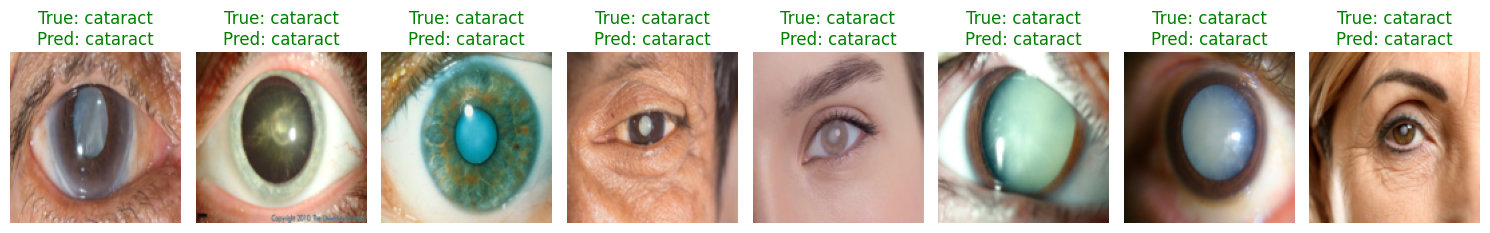

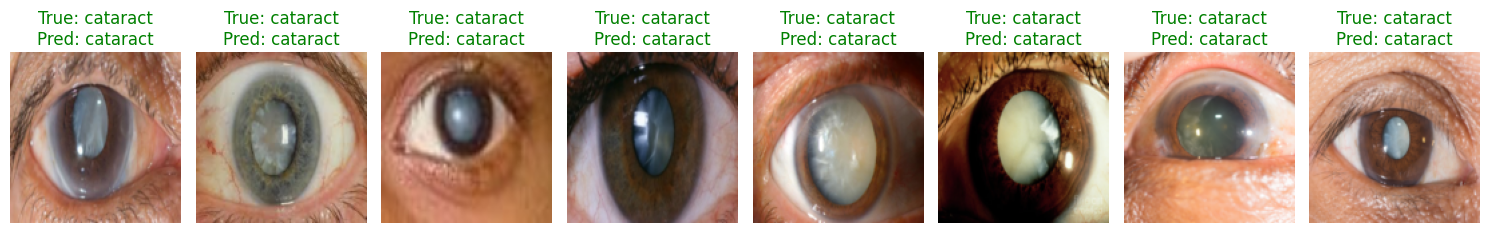

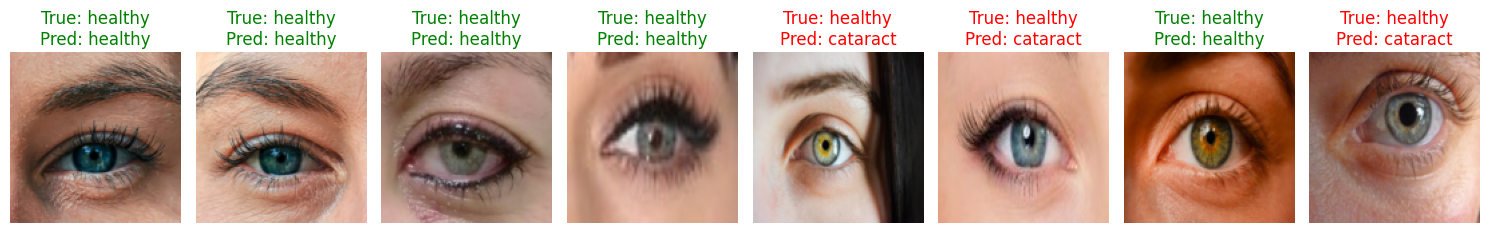

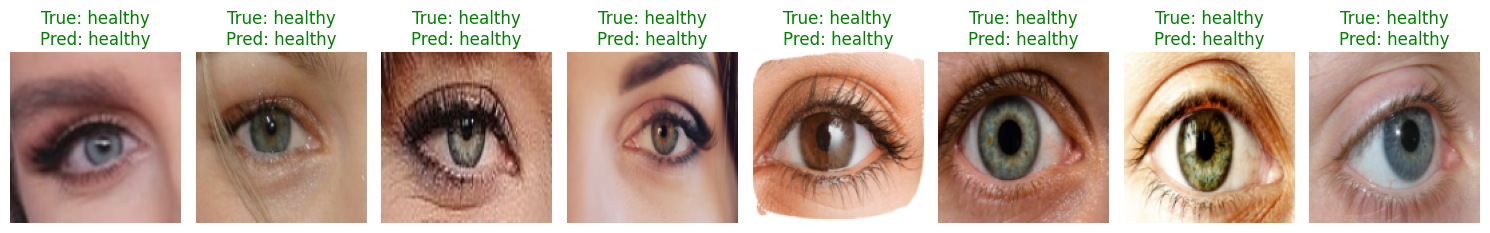

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

# Function to unnormalize and display images
def show_images(images, labels, preds, class_names, num_images=8):
    """
    Displays a grid of images with their actual and predicted labels.
    """
    # Convert images back to [0, 1] range
    images = images.cpu().numpy().transpose((0, 2, 3, 1))  # Convert to HWC format
    images = np.clip(images, 0, 1)  # Clip values to valid range

    fig, axes = plt.subplots(1, num_images, figsize=(15, 6))
    for i in range(num_images):
        ax = axes[i]
        ax.imshow(images[i])
        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color="green" if true_label == pred_label else "red")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Show all images in the validation set
class_names = validation_data.classes
num_images_to_show = 8  # Adjust as needed

with torch.no_grad():
    for images, labels in validation_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Unnormalize and display images with predictions and actual labels
        show_images(images, labels.cpu().numpy(), preds.cpu().numpy(), class_names, num_images=num_images_to_show)


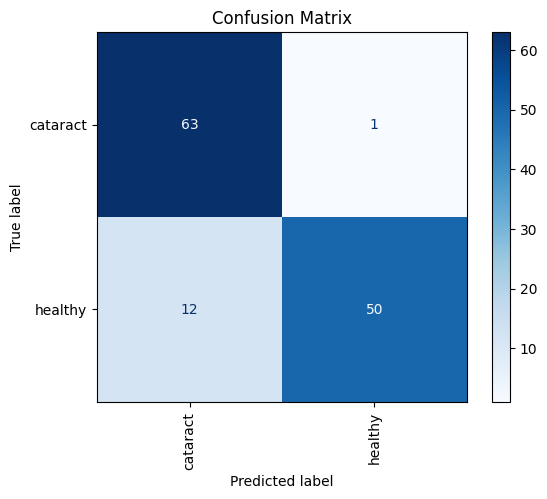

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=validation_data.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')  # Rotate labels for better readability
plt.title("Confusion Matrix")
plt.show()